<a href="https://colab.research.google.com/github/Jenifar5/Applied-ai/blob/main/IMAGE_TRANSFORMER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model ready.

Upload any image...


Saving pic1.jpg to pic1 (4).jpg


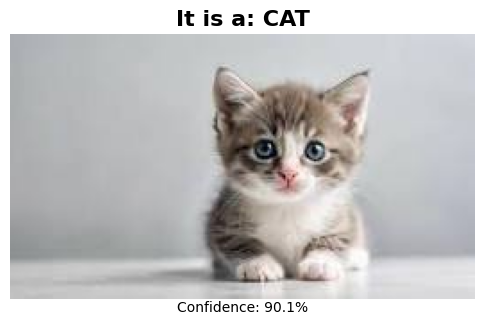

It is a: cat (90.1% confidence)


In [15]:
# Install required libraries (run once in Colab)
# !pip install transformers torch torchvision pillow

import warnings
warnings.filterwarnings("ignore")

from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import torch
import io

# -----------------------------
# Load CLIP Model
# -----------------------------
print("Loading CLIP model...")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("Model ready.\n")

# -----------------------------
# Upload Image
# -----------------------------
from google.colab import files
print("Upload any image...")
uploaded = files.upload()

# -----------------------------
# Candidate Labels
# -----------------------------
candidates = [
    "a cat", "a dog", "a car", "a bike", "a bus", "a truck",
    "a bird", "a horse", "a cow", "an elephant", "a lion", "a tiger",
    "a person", "a tree", "a flower", "a mountain", "a beach",
    "a building", "a bridge", "a road", "a river", "a sky",
    "a pizza", "a burger", "a cake", "a fruit", "a vegetable",
    "a phone", "a laptop", "a chair", "a table", "a bottle",
    "a boat", "a train", "an airplane", "a helicopter",
    "a fish", "a snake", "a frog", "a rabbit", "a bear",
    "a book", "a clock", "a cup", "a ball", "a bag"
]

# -----------------------------
# Prediction
# -----------------------------
for fname, fbytes in uploaded.items():
    img = Image.open(io.BytesIO(fbytes)).convert("RGB")

    inputs = processor(
        text=candidates,
        images=img,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1)[0]

    top_idx = probs.argmax().item()
    label = candidates[top_idx].replace("a ", "").replace("an ", "")
    confidence = probs[top_idx].item() * 100

    # -----------------------------
    # Display Result
    # -----------------------------
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.set_title(
        f"It is a: {label.upper()}",
        fontsize=16,
        fontweight='bold'
    )
    ax.text(
        0.5, -0.05,
        f"Confidence: {confidence:.1f}%",
        transform=ax.transAxes,
        ha='center'
    )
    ax.axis("off")
    plt.show()

    print(f"It is a: {label} ({confidence:.1f}% confidence)")